In [1]:
!pip install google_play_scraper
!pip install PySastrawi

from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.style.use('seaborn-v0_8-dark')
plt.rcParams["figure.figsize"] = (15,10)

In [2]:
#Android App OVO link from Google Play at
#https://play.google.com/store/apps/details?id=ovo.id
#The apps ID found in the link after id=ovo.id
#The apps name on Google Play titled: OVO
#Dated 08 March 2026: number of reviews 1.18M reviews

from google_play_scraper import app, Sort, reviews_all, reviews

ovo_reviews, _ = reviews(
    'ovo.id',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=50000 # Mengambil 50000 review terbaru
)

In [3]:
df_ovo = pd.DataFrame(ovo_reviews)
# Hapus baris yang content-nya kosong
df_ovo = df_ovo.dropna(subset=['content'])
df_ovo['content'] = df_ovo['content'].astype(str)

# Pilih kolom yang relevan
target_columns = ["content", "score", "thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]
existing_columns = [col for col in target_columns if col in df_ovo.columns]
df_ovo = df_ovo[existing_columns]

display(df_ovo.head())

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,parah ini ovo ya scan ke rek orang status berh...,1,0,None,2026-03-07 03:32:46,None,NaT
1,hati hati buat pengguna ovo ovo skrg jadi penc...,1,1,3.155.0,2026-03-07 03:30:46,None,NaT
2,sering update,5,0,None,2026-03-07 03:15:57,None,NaT
3,di saat d perlukan selalu error 👎🏻👎🏻,2,0,None,2026-03-07 02:53:16,None,NaT
4,ol,4,0,None,2026-03-07 02:47:27,None,NaT


In [4]:
print(df_ovo.reviewCreatedVersion.unique())
print(df_ovo.reviewCreatedVersion.nunique())

[None '3.155.0' '3.133.0' '3.153.0' '3.150.0' '3.121.0' '3.148.0'
 '3.154.0' '3.152.0' '3.81.0' '3.47.0' '3.141.0' '3.139.0' '3.54.0'
 '3.144.0' '3.130.0' '3.94.0' '3.140.0' '3.44.0' '3.143.0' '3.64.0'
 '3.134.0' '3.117.0' '3.116.0' '3.112.0' '3.138.0' '3.66.0' '3.100.0'
 '3.145.0' '3.136.0' '3.146.0' '3.22.1' '3.135.0' '3.35.0' '3.93.0'
 '3.149.0' '3.109.0' '3.111.0' '3.89.0' '3.77.0' '3.119.0' '3.126.0'
 '3.12.0' '3.51.1' '3.91.0' '3.129.2' '3.90.0' '3.127.0' '3.73.1'
 '3.122.0' '3.147.0' '3.75.1' '3.110.0' '3.124.0' '3.87.0' '3.108.0'
 '3.128.0' '3.132.0' '3.26.0' '3.102.0' '3.88.0' '3.34.0' '3.131.0'
 '3.96.0' '3.80.0' '3.61.0' '3.17.0' '3.103.0' '3.118.0' '3.137.0'
 '3.104.0' '3.86.0' '3.48.0' '3.84.1' '3.82.0' '3.115.0' '3.63.0' '3.72.0'
 '3.98.0' '3.71.0' '3.62.0' '3.107.0' '3.45.0' '3.113.0' '3.106.0'
 '3.105.0' '3.39.0' '3.123.0' '3.92.0' '3.56.0' '3.58.0' '3.70.1' '3.51.0'
 '3.95.0' '3.120.1' '3.69.1' '3.10.1' '3.50.1' '3.0.0' '3.52.1' '3.57.0'
 '3.36.0' '3.53.0' '3.97.0' '3.

In [5]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column
df_ovo.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,parah ini ovo ya scan ke rek orang status berh...,1,0,None,2026-03-07 03:32:46,None,NaT
1,hati hati buat pengguna ovo ovo skrg jadi penc...,1,1,3.155.0,2026-03-07 03:30:46,None,NaT
2,sering update,5,0,None,2026-03-07 03:15:57,None,NaT
3,di saat d perlukan selalu error 👎🏻👎🏻,2,0,None,2026-03-07 02:53:16,None,NaT
4,ol,4,0,None,2026-03-07 02:47:27,None,NaT
...,...,...,...,...,...,...,...
49995,OVO Emang seburuk ini ya? Masa pembayaran kelu...,1,0,3.112.0,2024-07-29 04:41:57,"Hai Kak Ulfi, maaf ya udah bikin nggak nyaman....",2024-07-29 04:42:58
49996,Pakai ove segalanya mudah,5,0,None,2024-07-29 04:18:05,None,NaT
49997,Luar biasa,5,0,3.112.0,2024-07-29 04:15:21,None,NaT
49998,Duit saya hilang disini saya transfer ovo ke b...,1,0,None,2024-07-29 04:10:16,"Hai Kak, maaf ya. Terkait dengan kendala yang ...",2024-07-29 04:13:59


In [6]:
# Tambahkan install Sastrawi (library NLP Indonesia)
!pip install emoji Sastrawi

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)

import regex
import nltk
import wordcloud
import textblob

# Download data NLTK yang diperlukan
nltk.download('stopwords')
nltk.download('punkt')
from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
# Ganti dengan Sastrawi (Khusus Indonesia)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Inisialisasi Stemmer Indonesia
factory = StemmerFactory()
stemmer_indo = factory.create_stemmer()

# Inisialisasi Stopwords Indonesia
factory_stop = StopWordRemoverFactory()
stopwords_indo_sastrawi = factory_stop.create_stop_word_remover()
# ------------------------------

from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [7]:
#Creating polarity on the column: content (review from the apps) using TextBlob
#Read https://textblob.readthedocs.io/en/dev/quickstart.html

from textblob import TextBlob

df_ovo['content'] = df_ovo['content'].fillna('')

df_ovo['sentiment_polarity'] = df_ovo['content'].apply(lambda x: TextBlob(x).polarity)
df_ovo['sentiment_subjective'] = df_ovo['content'].apply(lambda x: TextBlob(x).subjectivity)



In [8]:
#df_ovo.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","at"]]
df_ovo.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,"parah ini ovo ya scan ke rek orang status berhasil tapi saldo. ya tidak masuk, sudah tidak beres jadi pencuri skrg ovo hati hati buat pengguna ovo",1,0.0,0.0
1,hati hati buat pengguna ovo ovo skrg jadi pencuri uang kronologi scan ke org lain status berhasil tapi saldo tidak masuk awas ovo skrg sudah ga beres sudah mulai mencuri saldo pengguna dari ovo,1,0.0,0.0
2,sering update,5,0.0,0.0
3,di saat d perlukan selalu error 👎🏻👎🏻,2,0.0,0.0
4,ol,4,0.0,0.0
...,...,...,...,...
49995,"OVO Emang seburuk ini ya? Masa pembayaran keluar udh kepotong tapi gak masuk"" dananya? Udh email complain dan telp ke cs juga. Jawabannya butuh 3 hari kerja? Dan gak jelas ni dana bisa kebayar ata...",1,0.0,0.0
49996,Pakai ove segalanya mudah,5,0.0,0.0
49997,Luar biasa,5,0.0,0.0
49998,"Duit saya hilang disini saya transfer ovo ke bank saja tidak di proses"" sangat mengecewakan sekali",1,0.0,0.0


In [9]:
#Check number of reviews scores
print(df_ovo['score'].value_counts())

score
1    26664
5    15793
2     3182
3     2479
4     1882
Name: count, dtype: int64


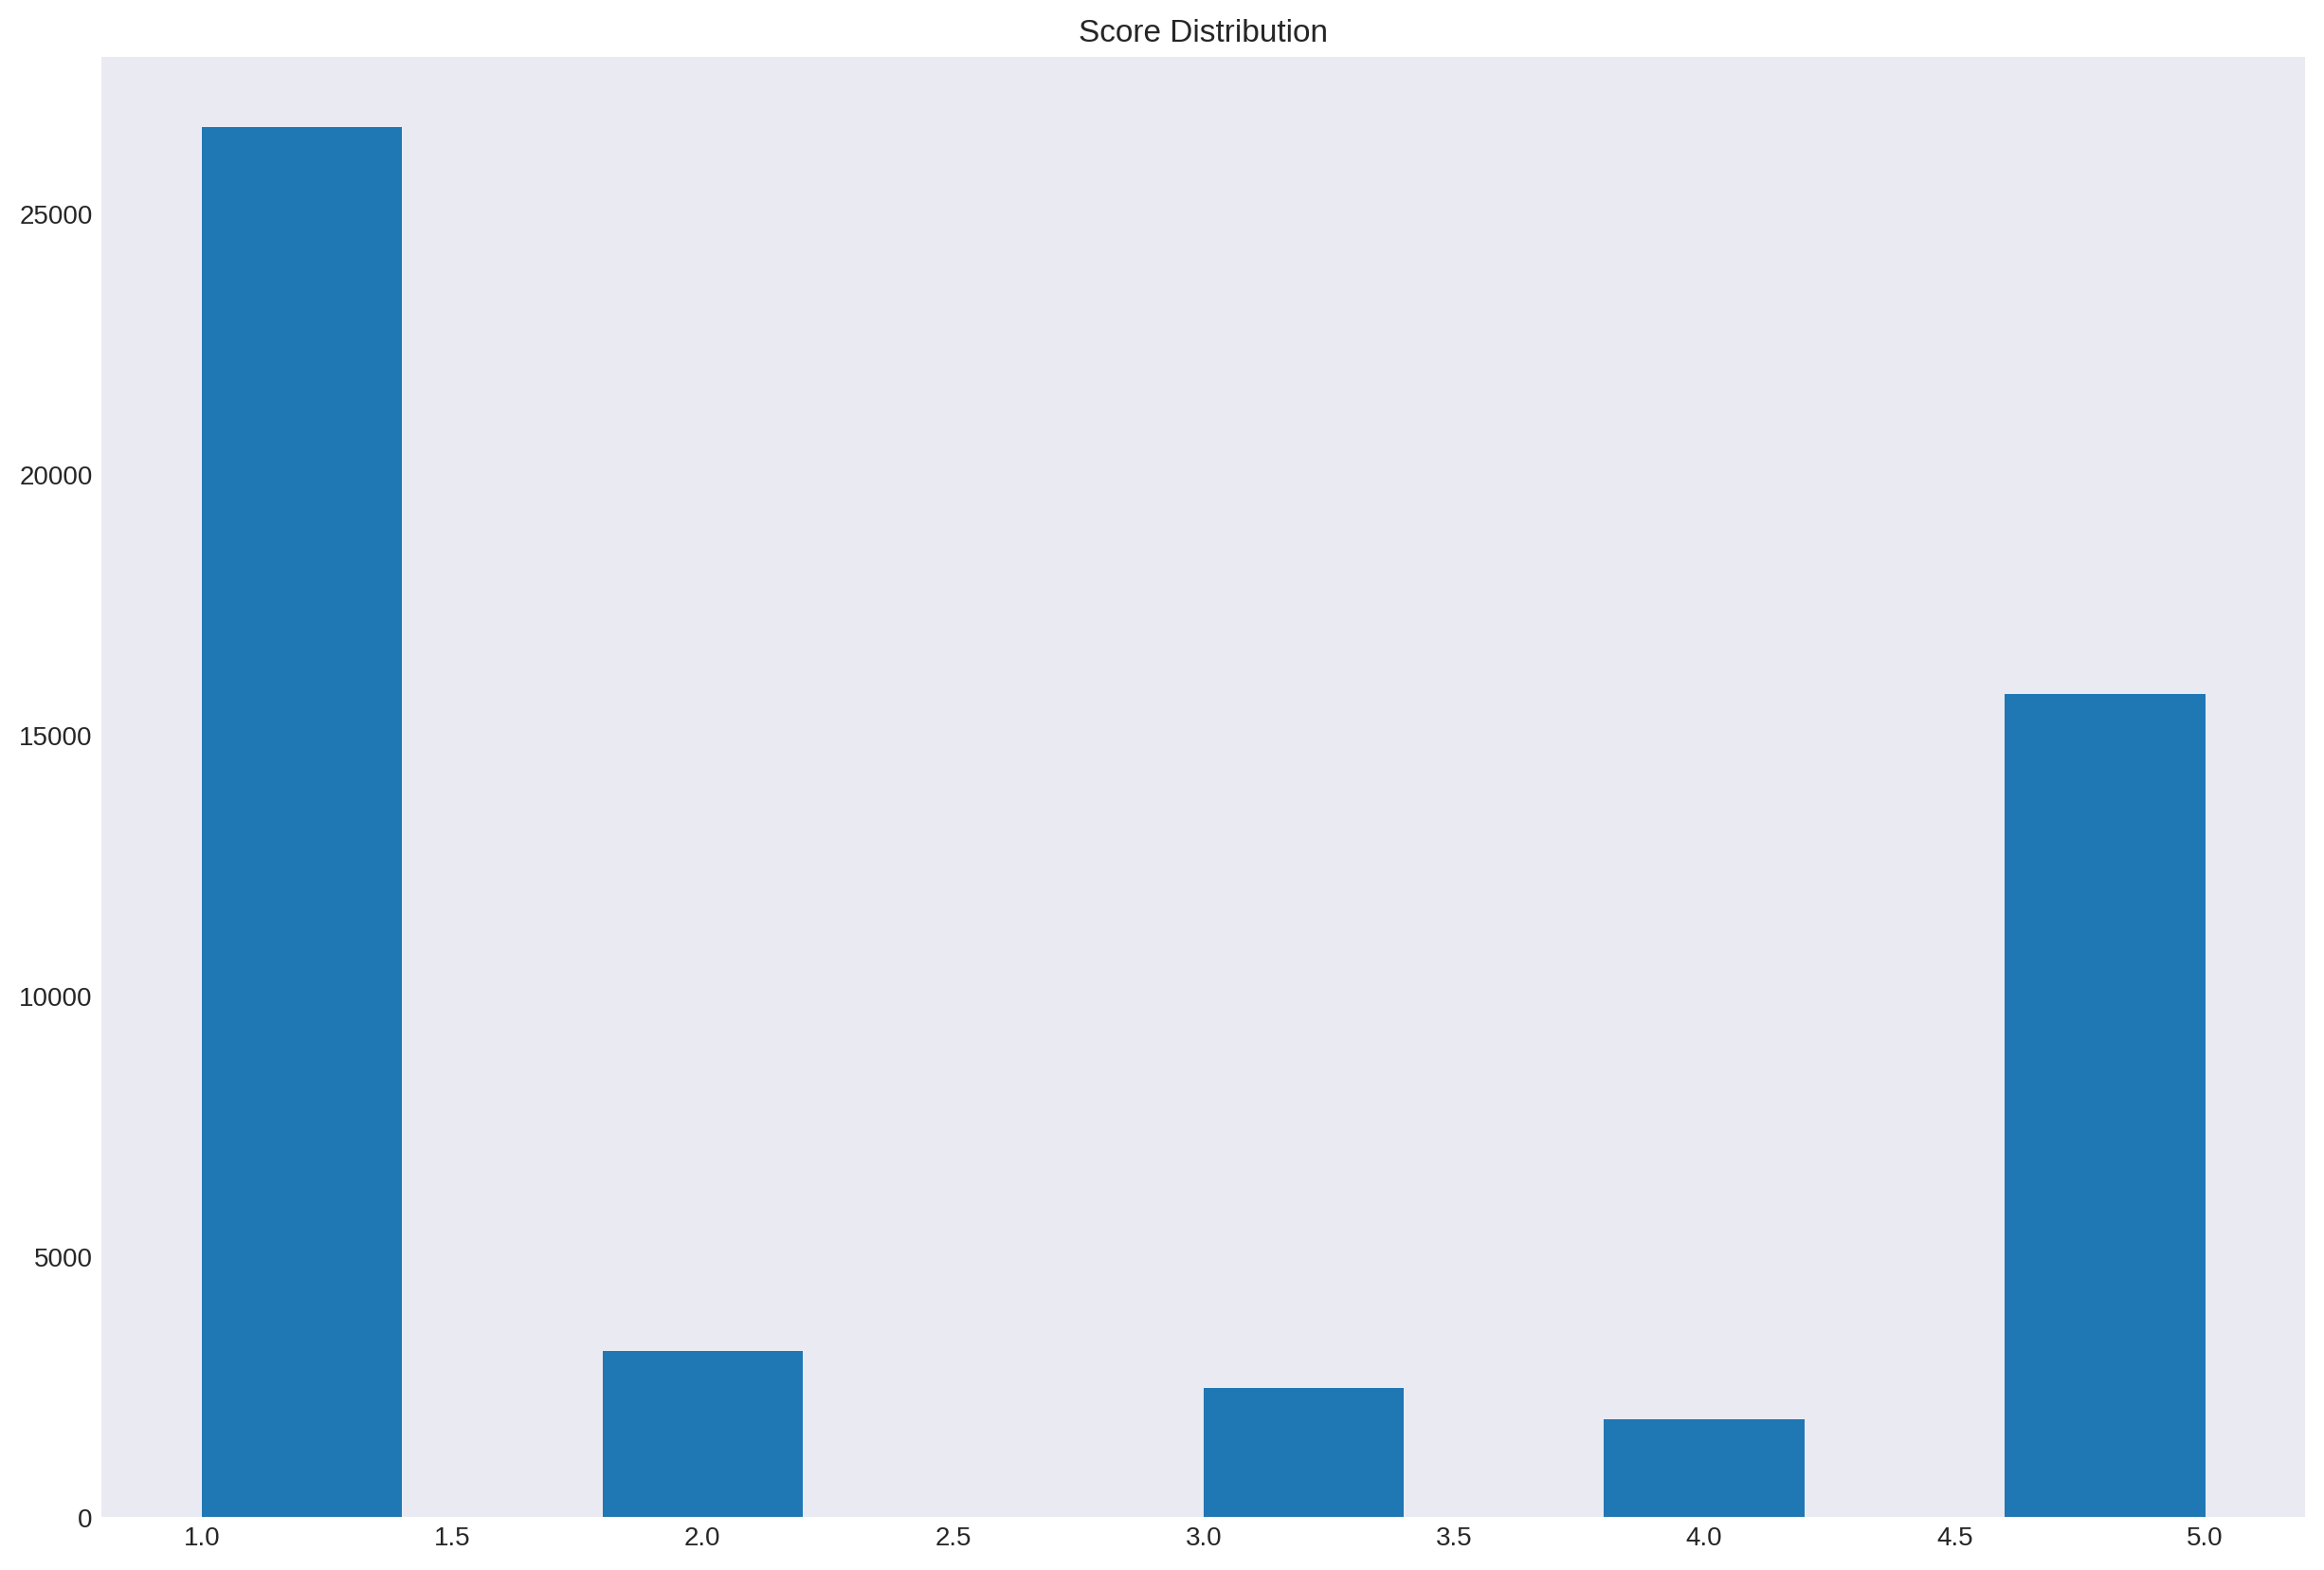

In [10]:
plt.hist(df_ovo['score'])
plt.title("Score Distribution")
plt.show()

In [11]:
# Change the reviews type to string
df_ovo['content'] = df_ovo['content'].astype(str)

In [12]:
#Lowercase all reviews to see the difference
df_ovo['content'] = df_ovo['content'].apply(lambda x: x.lower())

In [13]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_ovo['wordCount'] = [len(review.split()) for review in df_ovo['content']]

df_ovo['uppercaseCharCount'] = [sum(char.isupper() for char in review) \
                             for review in df_ovo['content']] # Akan 0 semua karena sudah di-lower() diatas

df_ovo['specialCharCount'] = [sum(char in string.punctuation for char in review) \
                            for review in df_ovo['content']]



In [15]:
df_ovo.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,"parah ini ovo ya scan ke rek orang status berhasil tapi saldo. ya tidak masuk, sudah tidak beres jadi pencuri skrg ovo hati hati buat pengguna ovo",1,0.0,0.0,27,0,2
1,hati hati buat pengguna ovo ovo skrg jadi pencuri uang kronologi scan ke org lain status berhasil tapi saldo tidak masuk awas ovo skrg sudah ga beres sudah mulai mencuri saldo pengguna dari ovo,1,0.0,0.0,34,0,0
2,sering update,5,0.0,0.0,2,0,0
3,di saat d perlukan selalu error 👎🏻👎🏻,2,0.0,0.0,7,0,0
4,ol,4,0.0,0.0,1,0,0
...,...,...,...,...,...,...,...
49995,"ovo emang seburuk ini ya? masa pembayaran keluar udh kepotong tapi gak masuk"" dananya? udh email complain dan telp ke cs juga. jawabannya butuh 3 hari kerja? dan gak jelas ni dana bisa kebayar ata...",1,0.0,0.0,61,0,16
49996,pakai ove segalanya mudah,5,0.0,0.0,4,0,0
49997,luar biasa,5,0.0,0.0,2,0,0
49998,"duit saya hilang disini saya transfer ovo ke bank saja tidak di proses"" sangat mengecewakan sekali",1,0.0,0.0,16,0,1


In [16]:
#Removing stopwords
#Using nltk
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize, sent_tokenize
from nltk import FreqDist
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer
from nltk.stem.wordnet import WordNetLemmatizer


from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

from string import punctuation

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [17]:
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  ax = sns.barplot(data=d, x= "word", y = "count")
  ax.set(ylabel = 'Count')
  plt.show()


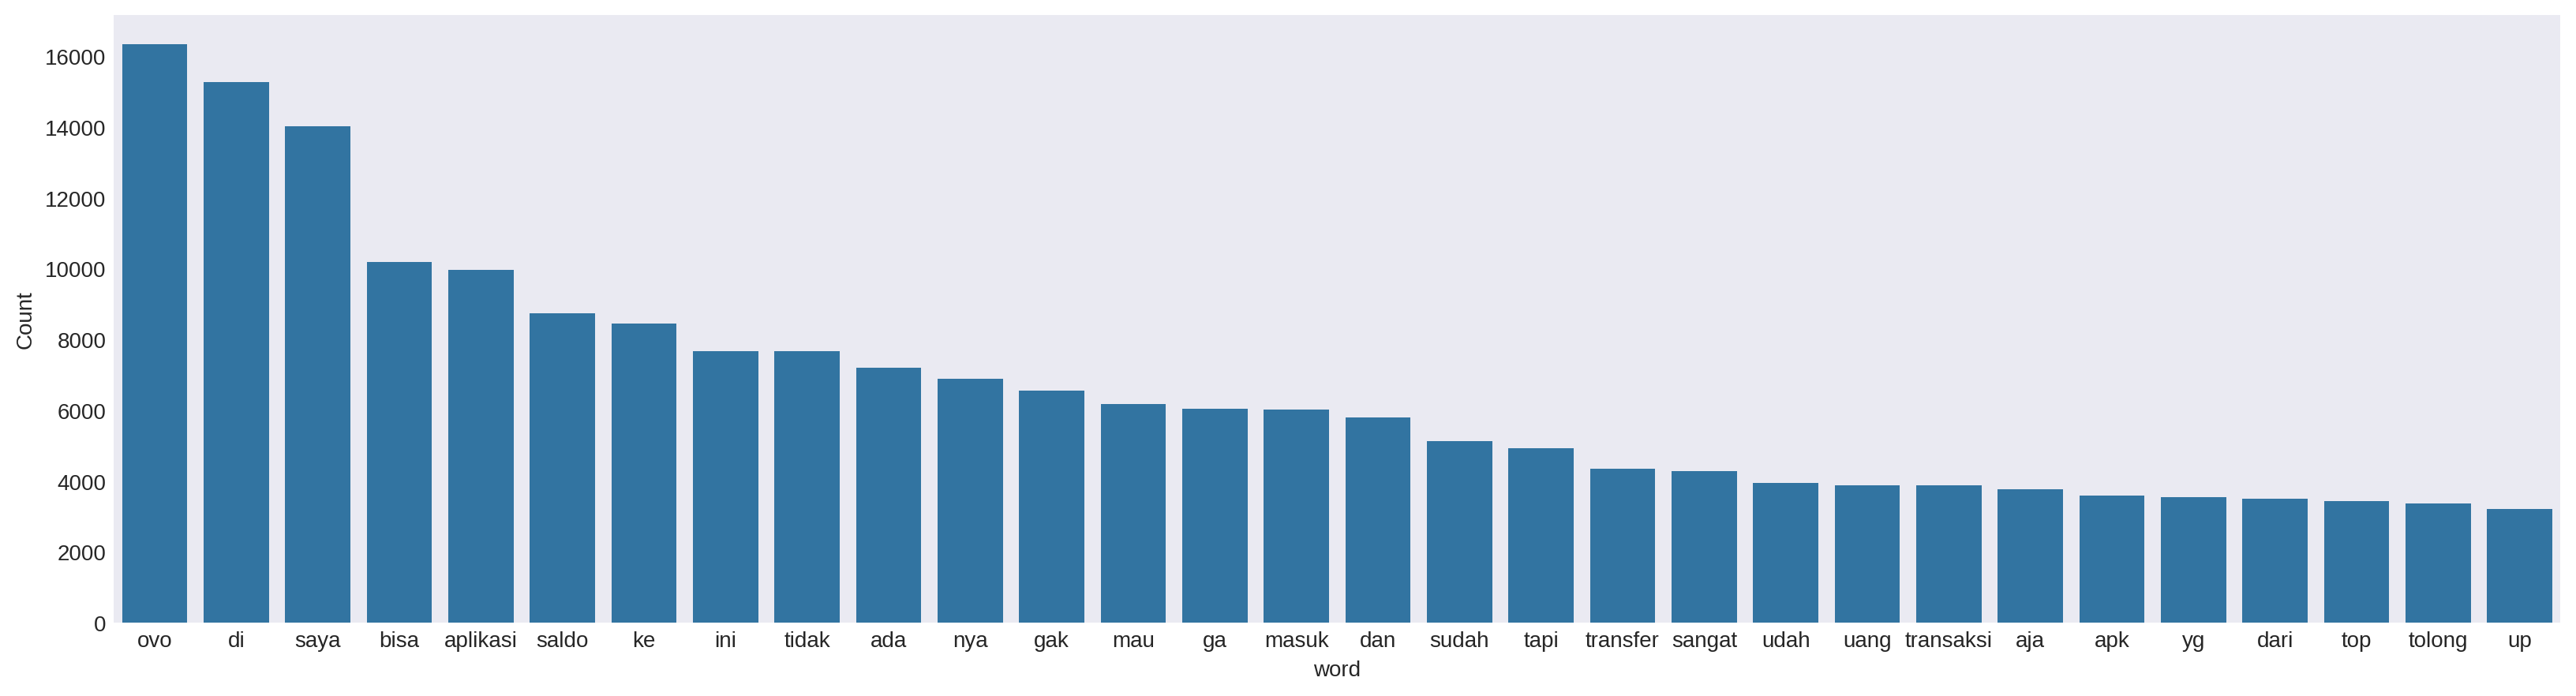

In [19]:
freq_words(df_ovo['content'])

In [21]:
#check if there is any special character
alphabet = string.ascii_letters+string.punctuation
print(df_ovo.content.str.strip(alphabet).astype(bool).any())

extracted_emojis=[]

def extract_emojis(s):
    expe = re.compile('[\U00010000-\U0010ffff]', flags=re.UNICODE)
    return expe.findall(s)

for y in df_ovo['content']:
    extracted_emojis.append(str(extract_emojis(y)))

print(extracted_emojis[:10]) # Print sample

True
['[]', '[]', '[]', "['👎', '🏻', '👎', '🏻']", '[]', '[]', '[]', '[]', '[]', '[]']


In [22]:
df_ovo.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,"parah ini ovo ya scan ke rek orang status berhasil tapi saldo. ya tidak masuk, sudah tidak beres jadi pencuri skrg ovo hati hati buat pengguna ovo",1,0.0,0.0,27,0,2
1,hati hati buat pengguna ovo ovo skrg jadi pencuri uang kronologi scan ke org lain status berhasil tapi saldo tidak masuk awas ovo skrg sudah ga beres sudah mulai mencuri saldo pengguna dari ovo,1,0.0,0.0,34,0,0
2,sering update,5,0.0,0.0,2,0,0
3,di saat d perlukan selalu error 👎🏻👎🏻,2,0.0,0.0,7,0,0
4,ol,4,0.0,0.0,1,0,0
...,...,...,...,...,...,...,...
49995,"ovo emang seburuk ini ya? masa pembayaran keluar udh kepotong tapi gak masuk"" dananya? udh email complain dan telp ke cs juga. jawabannya butuh 3 hari kerja? dan gak jelas ni dana bisa kebayar ata...",1,0.0,0.0,61,0,16
49996,pakai ove segalanya mudah,5,0.0,0.0,4,0,0
49997,luar biasa,5,0.0,0.0,2,0,0
49998,"duit saya hilang disini saya transfer ovo ke bank saja tidak di proses"" sangat mengecewakan sekali",1,0.0,0.0,16,0,1


In [23]:
#Add a column name polarity_rating from changing the score of the review into 3 labels: Pos, Negative Neutral
df_ovo['sentiment_rating'] = df_ovo['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))

In [24]:
df_ovo.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,"parah ini ovo ya scan ke rek orang status berhasil tapi saldo. ya tidak masuk, sudah tidak beres jadi pencuri skrg ovo hati hati buat pengguna ovo",1,0.0,0.0,Negative
1,hati hati buat pengguna ovo ovo skrg jadi pencuri uang kronologi scan ke org lain status berhasil tapi saldo tidak masuk awas ovo skrg sudah ga beres sudah mulai mencuri saldo pengguna dari ovo,1,0.0,0.0,Negative
2,sering update,5,0.0,0.0,Positive
3,di saat d perlukan selalu error 👎🏻👎🏻,2,0.0,0.0,Negative
4,ol,4,0.0,0.0,Positive
...,...,...,...,...,...
49995,"ovo emang seburuk ini ya? masa pembayaran keluar udh kepotong tapi gak masuk"" dananya? udh email complain dan telp ke cs juga. jawabannya butuh 3 hari kerja? dan gak jelas ni dana bisa kebayar ata...",1,0.0,0.0,Negative
49996,pakai ove segalanya mudah,5,0.0,0.0,Positive
49997,luar biasa,5,0.0,0.0,Positive
49998,"duit saya hilang disini saya transfer ovo ke bank saja tidak di proses"" sangat mengecewakan sekali",1,0.0,0.0,Negative


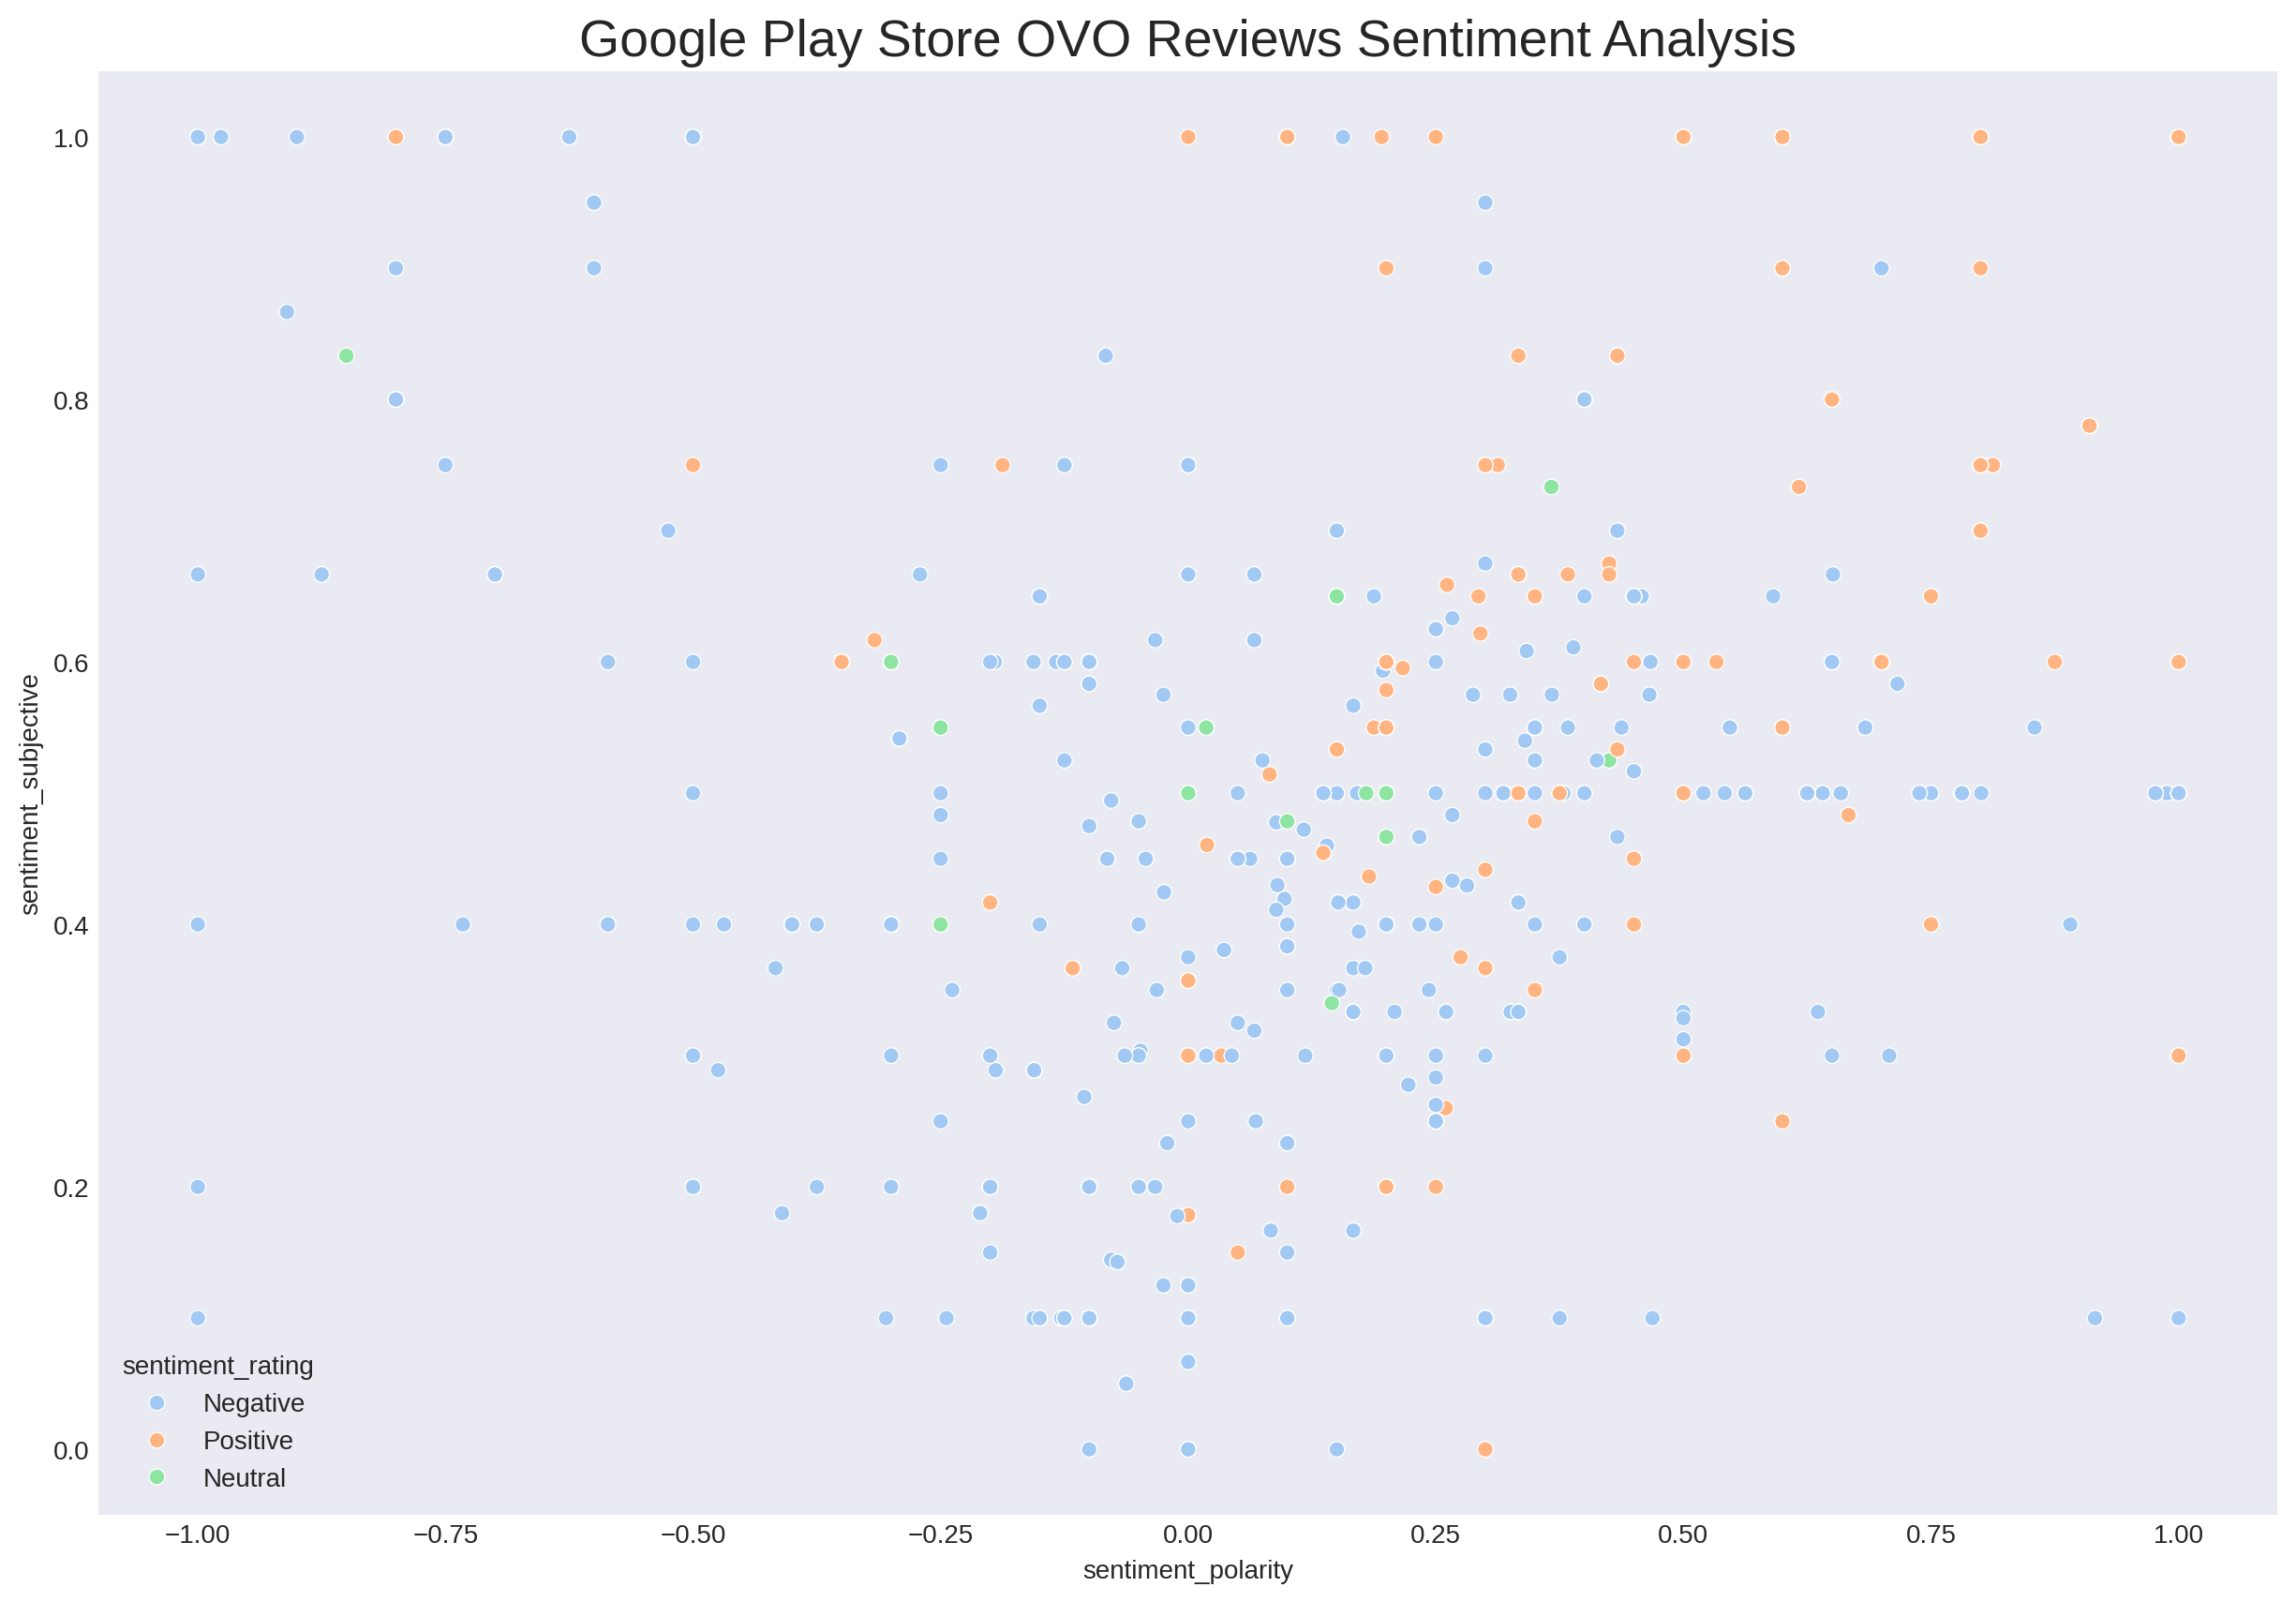

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=df_ovo,
    x='sentiment_polarity',
    y='sentiment_subjective',
    hue='sentiment_rating',
    edgecolor='white',
    palette="pastel"
)
plt.title("Google Play Store OVO Reviews Sentiment Analysis", fontsize=20)
plt.show()

In [27]:
from google.colab import files

# 1. Tentukan nama file saja (tanpa path D:\)
filename = 'df_ovo_before_stopwords_sentiment_rating.csv'

# 2. Simpan file ke penyimpanan sementara Colab
df_ovo.to_csv(filename, index=False)
print(f"File berhasil disimpan di cloud sebagai: {filename}")

# 3. Download file tersebut ke laptop kamu (browser akan otomatis mengunduh)
files.download(filename)

File berhasil disimpan di cloud sebagai: df_ovo_before_stopwords_sentiment_rating.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
import nltk
from nltk.corpus import stopwords
stop = stopwords.words('indonesian') + ["yg", "gak", "ga", "aja", "ini", "itu", "dan", "di", "ke"]
print(len(stop))

767


In [29]:
df_ovo_stopwords = df_ovo.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

In [30]:
# Exclude stopwords
df_ovo_stopwords['tweet_without_stopwords'] = df_ovo_stopwords['content'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))
print(df_ovo_stopwords)

                                                                                                                                                                                                       content  \
0                                                           parah ini ovo ya scan ke rek orang status berhasil tapi saldo. ya tidak masuk, sudah tidak beres jadi pencuri skrg ovo hati hati buat pengguna ovo   
1            hati hati buat pengguna ovo ovo skrg jadi pencuri uang kronologi scan ke org lain status berhasil tapi saldo tidak masuk awas ovo skrg sudah ga beres sudah mulai mencuri saldo pengguna dari ovo   
2                                                                                                                                                                                                sering update   
3                                                                                                                                                               

In [31]:
pat = r'\b(?:{})\b'.format('|'.join(stop))
# Note: regex replace ini bisa lambat untuk data besar, tapi dipertahankan sesuai struktur lama
# df_ovo_stopwords['tweet_without_stopwords'] = df_ovo_stopwords['content'].str.replace(pat, '')
df_ovo_stopwords['tweet_without_stopwords'] = df_ovo_stopwords['tweet_without_stopwords'].str.replace(r'\s+', ' ')

In [41]:
#Save into csv after applying stopwords
nama_file_2 = 'df_ovo_after_stopwords.csv'
df_ovo_stopwords.to_csv(nama_file_2, index=False)

print(f"Sedang mendownload: {nama_file_2} ...")
files.download(nama_file_2)

Sedang mendownload: df_ovo_after_stopwords.csv ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
#Count after stopwords
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_ovo_stopwords['wordCount'] = [len(review.split()) for review in df_ovo_stopwords['content']]
df_ovo_stopwords['wordCount_after_stopwords'] = [len(review.split()) for review in df_ovo_stopwords['tweet_without_stopwords']]



In [43]:
display(df_ovo_stopwords.loc[:,["content","score","sentiment_rating","wordCount","tweet_without_stopwords", "wordCount_after_stopwords"]].head())

,content,score,sentiment_rating,wordCount,tweet_without_stopwords,wordCount_after_stopwords
0,"parah ini ovo ya scan ke rek orang status berhasil tapi saldo. ya tidak masuk, sudah tidak beres jadi pencuri skrg ovo hati hati buat pengguna ovo",1,Negative,27,"parah ovo ya scan rek orang status berhasil saldo. ya masuk, beres pencuri skrg ovo hati hati pengguna ovo",19
1,hati hati buat pengguna ovo ovo skrg jadi pencuri uang kronologi scan ke org lain status berhasil tapi saldo tidak masuk awas ovo skrg sudah ga beres sudah mulai mencuri saldo pengguna dari ovo,1,Negative,34,hati hati pengguna ovo ovo skrg pencuri uang kronologi scan org status berhasil saldo masuk awas ovo skrg beres mencuri saldo pengguna ovo,23
2,sering update,5,Positive,2,update,1
3,di saat d perlukan selalu error 👎🏻👎🏻,2,Negative,7,d perlukan error 👎🏻👎🏻,4
4,ol,4,Positive,1,ol,1


In [44]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  ax = sns.barplot(data=d, x= "word", y = "count")
  ax.set(ylabel = 'Count')
  plt.show()

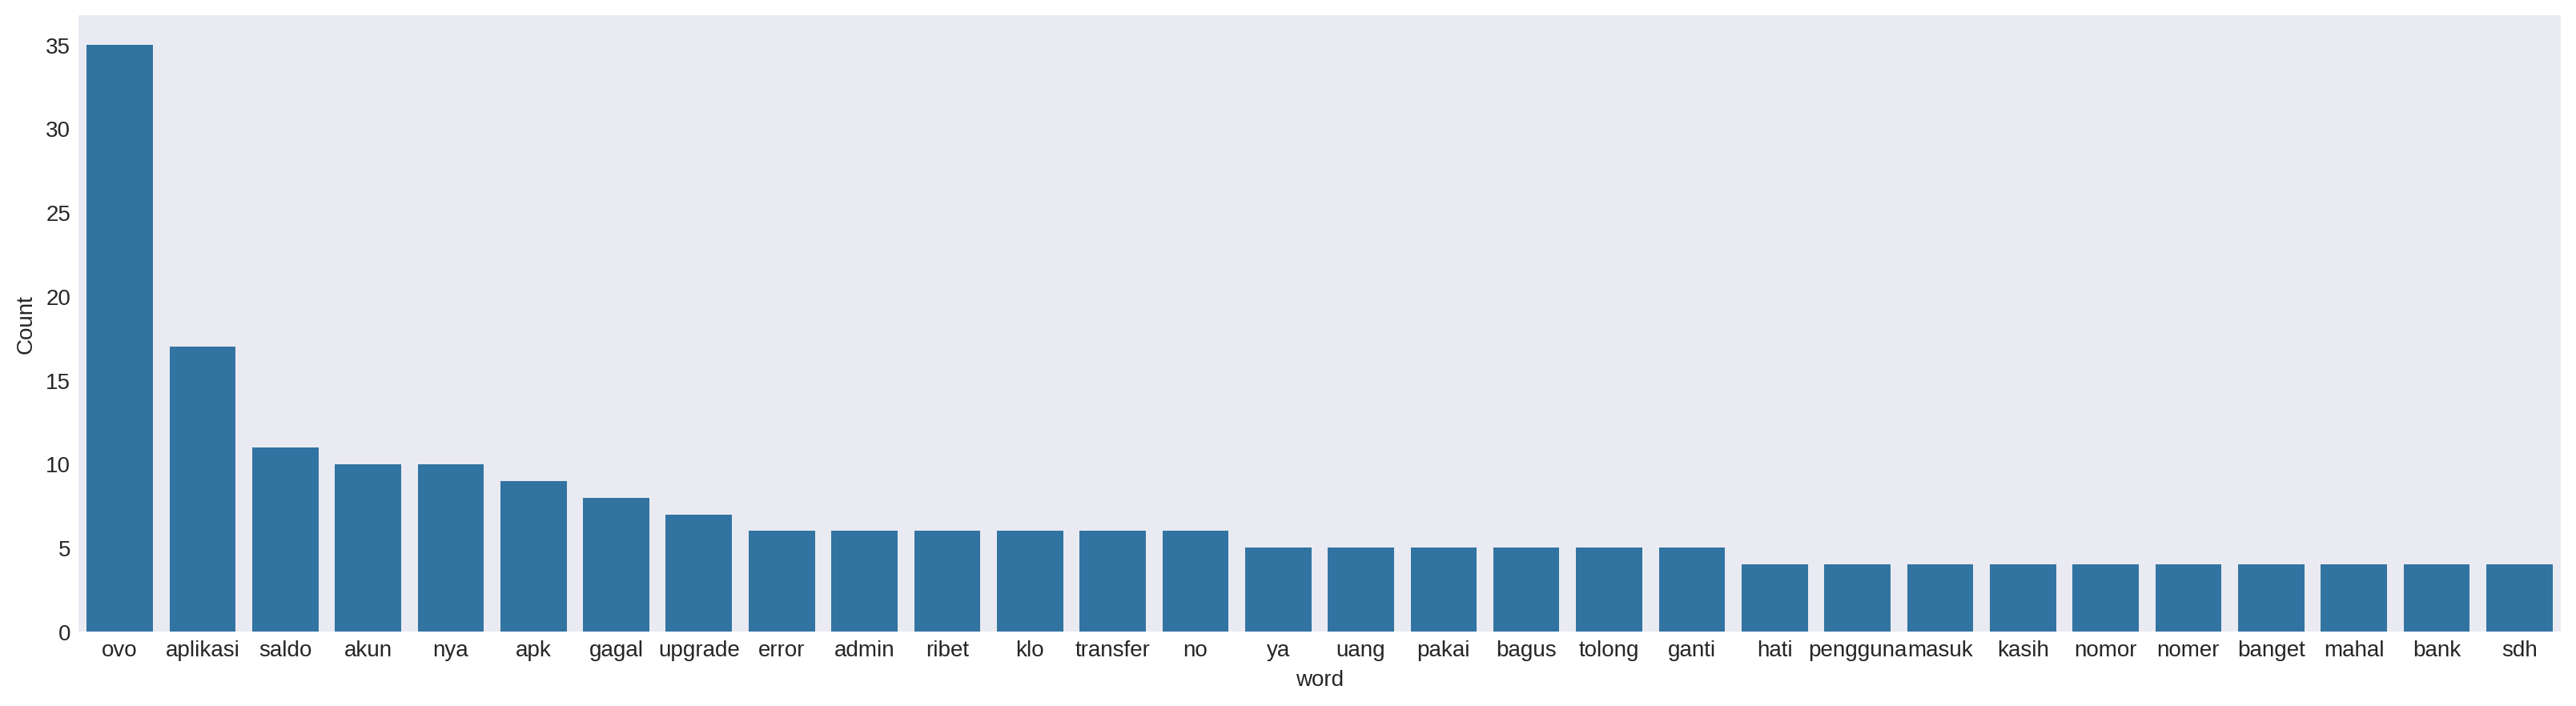

In [45]:
freq_words(df_ovo_stopwords['tweet_without_stopwords'])

In [46]:
def stemming(x):
    # Menggunakan stemmer_indo yang sudah di-init di atas
    if x is not None:
        return stemmer_indo.stem(x)
    return x

print("Mulai proses stemming... (Ini akan memakan waktu lama untuk 50k data)")
# Mengambil sampel 100 data saja agar cepat selesai untuk demo,
# Hapus .head(100) jika ingin memproses semua (bisa berjam-jam)
df_ovo_stopwords['tweet_stemmed'] = df_ovo_stopwords['tweet_without_stopwords'].head(100).apply(lambda x: stemming(x))

print("Contoh hasil stemming:")
print(df_ovo_stopwords['tweet_stemmed'].head())

Mulai proses stemming... (Ini akan memakan waktu lama untuk 50k data)
Contoh hasil stemming:
0                               parah ovo ya scan rek orang status hasil saldo ya masuk beres curi skrg ovo hati hati guna ovo
1    hati hati guna ovo ovo skrg curi uang kronologi scan org status hasil saldo masuk awas ovo skrg beres curi saldo guna ovo
2                                                                                                                       update
3                                                                                                                d perlu error
4                                                                                                                           ol
Name: tweet_stemmed, dtype: object


In [47]:
#===BIGRAM https://towardsdatascience.com/text-analysis-basics-in-python-443282942ec5 not yet
#Creating bigram/trigram to search

In [48]:
#DROP NA
df_ovo_stopwords.dropna(inplace=True)
df_ovo_stopwords.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   content                    100 non-null    object 
 1   score                      100 non-null    int64  
 2   sentiment_polarity         100 non-null    float64
 3   sentiment_subjective       100 non-null    float64
 4   sentiment_rating           100 non-null    object 
 5   tweet_without_stopwords    100 non-null    object 
 6   wordCount                  100 non-null    int64  
 7   wordCount_after_stopwords  100 non-null    int64  
 8   tweet_stemmed              100 non-null    object 
dtypes: float64(2), int64(3), object(4)
memory usage: 7.8+ KB


In [51]:
df_ovo_stopwords.loc[:,["content","score","sentiment_rating","wordCount","tweet_without_stopwords", "wordCount_after_stopwords"]]

,content,score,sentiment_rating,wordCount,tweet_without_stopwords,wordCount_after_stopwords
0,"parah ini ovo ya scan ke rek orang status berhasil tapi saldo. ya tidak masuk, sudah tidak beres jadi pencuri skrg ovo hati hati buat pengguna ovo",1,Negative,27,"parah ovo ya scan rek orang status berhasil saldo. ya masuk, beres pencuri skrg ovo hati hati pengguna ovo",19
1,hati hati buat pengguna ovo ovo skrg jadi pencuri uang kronologi scan ke org lain status berhasil tapi saldo tidak masuk awas ovo skrg sudah ga beres sudah mulai mencuri saldo pengguna dari ovo,1,Negative,34,hati hati pengguna ovo ovo skrg pencuri uang kronologi scan org status berhasil saldo masuk awas ovo skrg beres mencuri saldo pengguna ovo,23
2,sering update,5,Positive,2,update,1
3,di saat d perlukan selalu error 👎🏻👎🏻,2,Negative,7,d perlukan error 👎🏻👎🏻,4
4,ol,4,Positive,1,ol,1
...,...,...,...,...,...,...
95,ribet hrs upgrade ke ovo premier....mending upgrade ovo premier nya gampang...ini mah susah hrs ke kantor ovo. ribet dah pokoknya. aplikasi ovo gw bertahan msh ada krn terpaksa karna aplikasi grab...,1,Negative,39,"ribet hrs upgrade ovo premier....mending upgrade ovo premier nya gampang...ini mah susah hrs kantor ovo. ribet dah pokoknya. aplikasi ovo gw bertahan msh krn terpaksa karna aplikasi grab, klo krn ...",33
96,saldo dalam proses dari siang. kalo emang gak terkitim gagal kan aja lah. repot amat ni aplikasi,1,Negative,17,saldo proses siang. kalo emang terkitim gagal lah. repot ni aplikasi,11
97,gara-gara ovo ga bisa di upgrade lo ovo primer dana transfer ga bisa masuk pusat bantuan lewat email ga nyambung mending pikir lagi aja kalau mau pake ovo,1,Negative,28,gara-gara ovo upgrade lo ovo primer dana transfer masuk pusat bantuan email nyambung mending pikir pake ovo,17
98,"info di awal ada promo, sudah transaksi kuota habis, gini banget caranya vo, dmna-mana klo voucher sudah habis langsung info di awal",1,Negative,22,"info promo, transaksi kuota habis, gini banget vo, dmna-mana klo voucher habis langsung info",14
